## Ejercicio 1

arteix el conjunt de dadesDelayedFlights.csv en train i test. Estudia els dos conjunts per separat, a nivell descriptiu.

In [1]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import preprocessing
from sklearn.model_selection import train_test_split

# Configuracion para que se mestren todas las columnas
pd.set_option('display.max_columns', None)
# Configuracion para que los valores no se muestren con punto flotante
pd.options.display.float_format = '{:,.2f}'.format
# Lectura del fichero
df = pd.read_csv('DelayedFlights.csv')

# Normalizacion de los nombres de la columnas
df.columns = [col.lower() for col in df]

df.rename(columns={
    'dayofmonth': 'day_of_month', 
    'dayofweek': 'day_of_week',
    'crsdeptime': 'crs_dep_time',
    'crsarrtime': 'crs_arr_time',
    'uniquecarrier': 'unique_carrier',
    'actualelapsedtime': 'actual_elapsed_time',
    'crselapsedtime': 'crs_elapsed_time',
    'airtime': 'air_time',
    'arrdelay': 'arr_delay',
    'depdelay': 'dep_delay',
    'taxiout': 'taxi_out',
    'taxiin': 'taxi_in',
    'cancellationcode': 'cancellation_code',
    'carrierdelay': 'carrier_delay',
    'weatherdelay': 'weather_delay',
    'nasdelay': 'nas_delay',
    'securitydelay': 'security_delay',
    'lateaircraftdelay': 'late_air_craft_delay',
    'deptime': 'dep_time',
    'arrtime': 'arr_time',
    'tailnum': 'tail_num',
    'flightnum': 'flight_num'
    }, inplace=True)


In [2]:
# Eliminación de columnas
del df['tail_num']
del df['taxi_in']
del df['taxi_out']
del df['cancellation_code']
del df['year']

In [3]:
# Miramos como están relacionadas las variables
df.corr()

,unnamed: 0,month,day_of_month,day_of_week,dep_time,crs_dep_time,arr_time,crs_arr_time,flight_num,actual_elapsed_time,crs_elapsed_time,air_time,arr_delay,dep_delay,distance,cancelled,diverted,carrier_delay,weather_delay,nas_delay,security_delay,late_air_craft_delay
unnamed: 0,1.00,1.00,0.06,-0.00,-0.01,-0.01,-0.00,0.00,-0.02,0.03,0.03,0.02,0.00,0.01,0.03,0.03,0.01,0.00,0.01,0.02,-0.00,0.00
month,1.00,1.00,0.06,0.00,-0.01,-0.01,0.00,0.00,-0.00,0.00,0.01,0.00,-0.00,0.00,0.01,0.03,0.01,0.00,0.01,0.01,-0.00,0.00
day_of_month,0.06,0.06,1.00,0.02,0.00,0.00,0.00,0.00,-0.01,-0.00,-0.00,-0.00,0.00,0.01,0.00,0.00,0.00,-0.00,0.00,0.01,-0.00,0.01
day_of_week,-0.00,0.00,0.02,1.00,0.02,0.03,0.01,0.02,-0.01,0.00,0.00,0.00,0.01,0.01,0.01,0.00,-0.00,0.01,0.01,-0.01,0.00,0.01
dep_time,-0.01,-0.01,0.00,0.02,1.00,0.88,0.46,0.71,-0.02,-0.05,-0.04,-0.05,0.13,0.14,-0.06,0.00,-0.00,-0.05,0.01,0.02,-0.02,0.17
crs_dep_time,-0.01,-0.01,0.00,0.03,0.88,1.00,0.40,0.71,-0.05,-0.03,-0.03,-0.04,0.04,0.06,-0.03,0.00,-0.01,-0.11,-0.01,-0.03,-0.02,0.17
arr_time,-0.00,0.00,0.00,0.01,0.46,0.40,1.00,0.62,-0.01,-0.01,-0.01,-0.02,-0.05,-0.05,-0.03,nan,-0.01,-0.08,-0.03,0.03,-0.01,-0.04
crs_arr_time,0.00,0.00,0.00,0.02,0.71,0.71,0.62,1.00,-0.06,0.03,0.04,0.03,0.04,0.05,0.02,0.00,0.00,-0.10,-0.01,0.01,-0.01,0.13
flight_num,-0.02,-0.00,-0.01,-0.01,-0.02,-0.05,-0.01,-0.06,1.00,-0.32,-0.34,-0.34,0.06,0.05,-0.36,0.01,-0.00,0.06,0.07,0.02,-0.00,-0.05
actual_elapsed_time,0.03,0.00,-0.00,0.00,-0.05,-0.03,-0.01,0.03,-0.32,1.00,0.97,0.98,0.07,0.02,0.95,nan,nan,0.01,0.00,0.18,0.01,-0.03


Podemos observar una relación entre estas variales
* arr_delay y dep_delay
* arr_delay y late_air_craft_delay
* arr_delay y carrier_delay

Nuestra variable objetivo va a ser **arr_delay**, para predecir cuántos minutos se trasará el vuelo.

Nos quedaremos solamente con las columnas que están relacionas con esta y **unique_carrier**, para saber a quién corresponde.

In [4]:
df_arr_delay = df[['unique_carrier','carrier_delay', 'dep_delay', 'late_air_craft_delay', 'arr_delay']]

Veamos los datos que tenemos

In [5]:
df_arr_delay.isnull().sum()

unique_carrier               0
carrier_delay           689270
dep_delay                    0
late_air_craft_delay    689270
arr_delay                 8387
dtype: int64

In [6]:
df['diverted'][((df['diverted'] == 1) | (df['cancelled'] == 1))].count()

8387

Los nulos de arr_delay son porque el vuelo fue cancelado o desviado, por lo que podemos asignar 0 en esa columna para estos casos.

In [7]:
df_arr_delay.fillna({'arr_delay':0}, inplace=True)

C:\Users\Ale\anaconda3\lib\site-packages\pandas\core\series.py:4517: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return super().fillna(


In [8]:
df[(df['carrier_delay'].isnull())].describe()

,unnamed: 0,month,day_of_month,day_of_week,dep_time,crs_dep_time,arr_time,crs_arr_time,flight_num,actual_elapsed_time,crs_elapsed_time,air_time,arr_delay,dep_delay,distance,cancelled,diverted,carrier_delay,weather_delay,nas_delay,security_delay,late_air_craft_delay
count,"689,270.00","689,270.00","689,270.00","689,270.00","689,270.00","689,270.00","682,160.00","689,270.00","689,270.00","680,883.00","689,072.00","680,883.00","680,883.00","689,270.00","689,270.00","689,270.00","689,270.00",0.00,0.00,0.00,0.00,0.00
mean,"3,381,718.43",6.19,15.80,3.99,"1,445.60","1,430.41","1,598.05","1,601.23","2,017.27",129.51,138.90,109.85,3.56,13.34,809.30,0.00,0.01,nan,nan,nan,nan,nan
std,"2,040,860.58",3.43,8.75,2.00,434.03,428.71,475.64,468.03,"1,833.45",71.47,74.29,69.46,7.84,11.96,598.41,0.03,0.11,nan,nan,nan,nan,nan
min,0.00,1.00,1.00,1.00,1.00,0.00,1.00,0.00,1.00,15.00,-25.00,0.00,-109.00,6.00,30.00,0.00,0.00,nan,nan,nan,nan,nan
25%,"1,587,626.50",3.00,8.00,2.00,"1,120.00","1,110.00","1,301.00","1,300.00",558.00,76.00,84.00,58.00,-1.00,8.00,363.00,0.00,0.00,nan,nan,nan,nan,nan
50%,"3,303,757.50",6.00,16.00,4.00,"1,450.00","1,440.00","1,639.00","1,639.00","1,462.00",112.00,120.00,92.00,5.00,11.00,641.00,0.00,0.00,nan,nan,nan,nan,nan
75%,"5,061,119.50",9.00,23.00,6.00,"1,806.00","1,755.00","1,955.00","1,955.00","3,008.00",160.00,170.00,139.00,10.00,16.00,"1,050.00",0.00,0.00,nan,nan,nan,nan,nan
max,"7,009,727.00",12.00,31.00,7.00,"2,400.00","2,359.00","2,400.00","2,400.00","9,742.00",664.00,660.00,631.00,14.00,"1,154.00","4,962.00",1.00,1.00,nan,nan,nan,nan,nan


Los **carrier_delay** con null son casos donde el **arrar_delay** es de un máximo de 14 minutos. No tenemos datos para vuelos con menos de esos minutos de retraso. Por ende los consideraremos como no retrasados.

In [9]:
df_arr_delay.fillna({'carrier_delay':0, 'late_air_craft_delay':0}, inplace=True)
df_arr_delay.isnull().sum()

C:\Users\Ale\anaconda3\lib\site-packages\pandas\core\series.py:4517: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return super().fillna(


unique_carrier          0
carrier_delay           0
dep_delay               0
late_air_craft_delay    0
arr_delay               0
dtype: int64

In [10]:
df_arr_delay.describe()

,carrier_delay,dep_delay,late_air_craft_delay,arr_delay
count,"1,936,758.00","1,936,758.00","1,936,758.00","1,936,758.00"
mean,12.35,43.19,16.29,42.02
std,36.13,53.40,35.86,56.73
min,0.00,6.00,0.00,-109.00
25%,0.00,12.00,0.00,9.00
50%,0.00,24.00,0.00,24.00
75%,10.00,53.00,18.00,55.00
max,"2,436.00","2,467.00","1,316.00","2,461.00"


Ya tenemos nuestro data set limpio para poder generar los datos de entrenamiento y prueba, donde tendran el 70 y el 30 porciento respectivamente.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(df_arr_delay[['unique_carrier','carrier_delay','dep_delay','late_air_craft_delay']], df_arr_delay['arr_delay'], test_size=0.30)

In [12]:
X_train.describe()

,carrier_delay,dep_delay,late_air_craft_delay
count,"1,355,730.00","1,355,730.00","1,355,730.00"
mean,12.33,43.18,16.30
std,35.92,53.33,35.82
min,0.00,6.00,0.00
25%,0.00,12.00,0.00
50%,0.00,24.00,0.00
75%,10.00,53.00,18.00
max,"1,552.00","2,457.00","1,316.00"


In [13]:
X_test.describe()

,carrier_delay,dep_delay,late_air_craft_delay
count,"581,028.00","581,028.00","581,028.00"
mean,12.41,43.21,16.28
std,36.63,53.57,35.94
min,0.00,6.00,0.00
25%,0.00,12.00,0.00
50%,0.00,24.00,0.00
75%,9.00,53.00,18.00
max,"2,436.00","2,467.00",994.00


Las features de entrenamiento y test son bastantes similares. El minimo y la mediana son iguales para las 3 variables.
En el promedio y la desviación hay una pequeña diferencia que de ser por los distintos outliers.

Text(0.5, 1.0, 'Late Air Craft Delay Test')

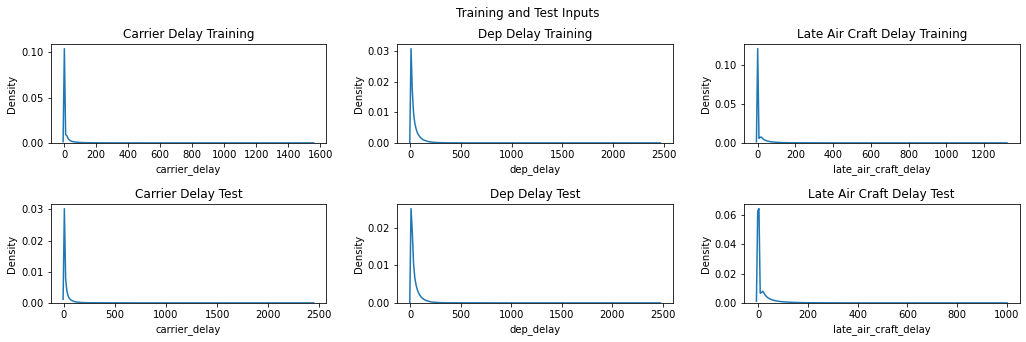

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(15, 5))
plt.tight_layout(pad=4.0)
fig.suptitle('Training and Test Inputs')

sns.kdeplot(ax=axes[0,0], data=X_train, x="carrier_delay")
axes[0,0].set_title('Carrier Delay Training')

sns.kdeplot(ax=axes[0,1], data=X_train, x="dep_delay")
axes[0,1].set_title('Dep Delay Training')

sns.kdeplot(ax=axes[0,2], data=X_train, x="late_air_craft_delay")
axes[0,2].set_title('Late Air Craft Delay Training')

sns.kdeplot(ax=axes[1,0], data=X_test, x="carrier_delay")
axes[1,0].set_title('Carrier Delay Test')

sns.kdeplot(ax=axes[1,1], data=X_test, x="dep_delay")
axes[1,1].set_title('Dep Delay Test')

sns.kdeplot(ax=axes[1,2], data=X_test, x="late_air_craft_delay")
axes[1,2].set_title('Late Air Craft Delay Test')

En el grafico de arriba podemos observar la similitud de de los conjuntos de test y entrenamiento

In [15]:
y_train.describe()

count   1,355,730.00
mean           42.00
std            56.67
min          -109.00
25%             9.00
50%            24.00
75%            55.00
max         2,461.00
Name: arr_delay, dtype: float64

<AxesSubplot:xlabel='arr_delay'>

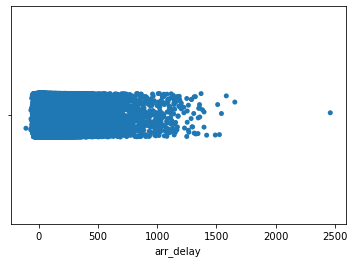

In [16]:
df_y_train=pd.DataFrame({'arr_delay':y_train})
sns.stripplot(x=df_y_train["arr_delay"])

In [17]:
y_test.describe()

count   581,028.00
mean         42.05
std          56.87
min         -70.00
25%           9.00
50%          24.00
75%          55.00
max       2,453.00
Name: arr_delay, dtype: float64

<AxesSubplot:xlabel='arr_delay'>

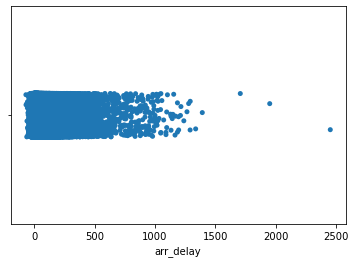

In [18]:
df_y_test=pd.DataFrame({'arr_delay':y_test})
sns.stripplot(x=df_y_test["arr_delay"])

Podemos observar que la variable objetivo del conjunto de entrenamiento y test también se asemejan. Gran parte de la distribución está entre 0 y 500 en ambos, y en los dos conjuntos hay outliers.

## Ejercicio 2

Aplica algun procés de transformació (estandarditzar les dades numèriques, crear columnes dummies, polinomis...).

In [19]:
X_train.head()

,unique_carrier,carrier_delay,dep_delay,late_air_craft_delay
1622520,CO,0.00,10.00,0.00
1563744,UA,0.00,33.00,0.00
1641539,WN,0.00,7.00,0.00
1249979,CO,16.00,19.00,0.00
1917117,B6,0.00,16.00,0.00


In [20]:
X_train.describe()

,carrier_delay,dep_delay,late_air_craft_delay
count,"1,355,730.00","1,355,730.00","1,355,730.00"
mean,12.33,43.18,16.30
std,35.92,53.33,35.82
min,0.00,6.00,0.00
25%,0.00,12.00,0.00
50%,0.00,24.00,0.00
75%,10.00,53.00,18.00
max,"1,552.00","2,457.00","1,316.00"


Aunque las unidades se las variables sean las mismas (minutos), sus valores varían bastante, y los valores grandes podrían afectar al modelo.

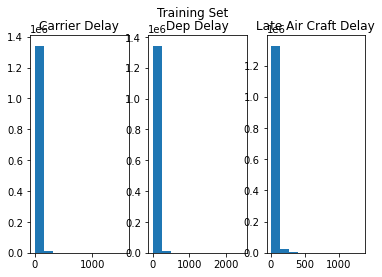

In [21]:
plt.subplot(1, 3, 1)
plt.hist(X_train["carrier_delay"])
plt.title("Carrier Delay")

plt.subplot(1, 3, 2)
plt.hist(X_train["dep_delay"])
plt.title("Dep Delay")

plt.subplot(1, 3, 3)
plt.hist(X_train["late_air_craft_delay"])
plt.title("Late Air Craft Delay")

plt.suptitle("Training Set")
plt.show()

Normalizaremos los valores para que sean más comparables.

In [22]:
min_max_scaler = preprocessing.MinMaxScaler()
X_train_transformed = X_train.copy()
X_train_minmax = min_max_scaler.fit_transform(X_train[["carrier_delay",'dep_delay','late_air_craft_delay']])


In [23]:
scaled_features_df = pd.DataFrame(X_train_minmax, index=X_train.index, columns=["carrier_delay",'dep_delay','late_air_craft_delay'])

In [24]:
X_train_transformed["carrier_delay"] = scaled_features_df["carrier_delay"]
X_train_transformed['dep_delay'] = scaled_features_df['dep_delay']
X_train_transformed['late_air_craft_delay'] = scaled_features_df['late_air_craft_delay']
X_train_transformed.describe()

,carrier_delay,dep_delay,late_air_craft_delay
count,"1,355,730.00","1,355,730.00","1,355,730.00"
mean,0.01,0.02,0.01
std,0.02,0.02,0.03
min,0.00,0.00,0.00
25%,0.00,0.00,0.00
50%,0.00,0.01,0.00
75%,0.01,0.02,0.01
max,1.00,1.00,1.00


Podemos ver ahora que las variables estan en un rango de 0 a 1 haciendo que sean más comparables.

**unique_carrier** es una variable categorica, estos tipos de datos no son entendidos por los algoritmos, por lo que aplicaremos una transformación para puedan ser interpretados, generando colummnas dummies por cada categoria.

In [25]:
X_train_transformed  = pd.get_dummies(X_train_transformed, prefix=['carr'], columns=['unique_carrier'])
X_train_transformed

,carrier_delay,dep_delay,late_air_craft_delay,carr_9E,carr_AA,carr_AQ,carr_AS,carr_B6,carr_CO,carr_DL,carr_EV,carr_F9,carr_FL,carr_HA,carr_MQ,carr_NW,carr_OH,carr_OO,carr_UA,carr_US,carr_WN,carr_XE,carr_YV
1622520,0.00,0.00,0.00,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1563744,0.00,0.01,0.00,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
1641539,0.00,0.00,0.00,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
1249979,0.01,0.01,0.00,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1917117,0.00,0.00,0.00,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
674715,0.01,0.00,0.00,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
1476673,0.00,0.01,0.01,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
597321,0.00,0.00,0.00,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
1315770,0.00,0.00,0.00,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0


Ya tenemos nuestro data set de entrenamiento listo.

## Ejercicio 3

Resumeix les noves columnes generades de manera estadística i gràfica

In [26]:
X_train_transformed.describe()

,carrier_delay,dep_delay,late_air_craft_delay,carr_9E,carr_AA,carr_AQ,carr_AS,carr_B6,carr_CO,carr_DL,carr_EV,carr_F9,carr_FL,carr_HA,carr_MQ,carr_NW,carr_OH,carr_OO,carr_UA,carr_US,carr_WN,carr_XE,carr_YV
count,"1,355,730.00","1,355,730.00","1,355,730.00","1,355,730.00","1,355,730.00","1,355,730.00","1,355,730.00","1,355,730.00","1,355,730.00","1,355,730.00","1,355,730.00","1,355,730.00","1,355,730.00","1,355,730.00","1,355,730.00","1,355,730.00","1,355,730.00","1,355,730.00","1,355,730.00","1,355,730.00","1,355,730.00","1,355,730.00","1,355,730.00"
mean,0.01,0.02,0.01,0.03,0.10,0.00,0.02,0.03,0.05,0.06,0.04,0.01,0.04,0.00,0.07,0.04,0.03,0.07,0.07,0.05,0.19,0.05,0.03
std,0.02,0.02,0.03,0.16,0.30,0.02,0.14,0.17,0.22,0.24,0.20,0.12,0.19,0.06,0.26,0.20,0.16,0.25,0.26,0.22,0.40,0.23,0.18
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,0.00,0.01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
75%,0.01,0.02,0.01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
max,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00


Podemos observar que los nuevos rangos de las variables numéricas van de 0 a 1, y ahora son más faciles de comparar.
Por otra parte las variables de categorias tienen máximo 1 ya con este valor se indica que corresponde a ese carrier.

Text(0.5, 1.0, 'Late Air Craft Delay Transformed')

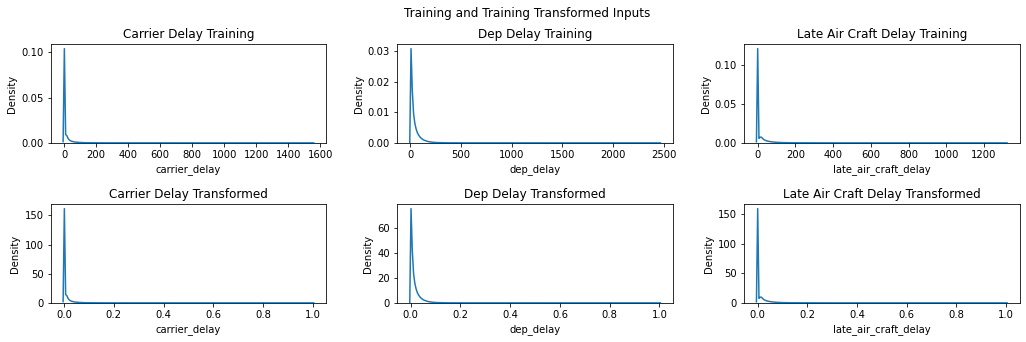

In [27]:
fig, axes = plt.subplots(2, 3, figsize=(15, 5))
plt.tight_layout(pad=4.0)
fig.suptitle('Training and Training Transformed Inputs')

sns.kdeplot(ax=axes[0,0], data=X_train, x="carrier_delay")
axes[0,0].set_title('Carrier Delay Training')

sns.kdeplot(ax=axes[0,1], data=X_train, x="dep_delay")
axes[0,1].set_title('Dep Delay Training')

sns.kdeplot(ax=axes[0,2], data=X_train, x="late_air_craft_delay")
axes[0,2].set_title('Late Air Craft Delay Training')

sns.kdeplot(ax=axes[1,0], data=X_train_transformed, x="carrier_delay")
axes[1,0].set_title('Carrier Delay Transformed')

sns.kdeplot(ax=axes[1,1], data=X_train_transformed, x="dep_delay")
axes[1,1].set_title('Dep Delay Transformed')

sns.kdeplot(ax=axes[1,2], data=X_train_transformed, x="late_air_craft_delay")
axes[1,2].set_title('Late Air Craft Delay Transformed')

Aqui podemos observar cómo después de la distribución las variables varían en el rango de 0 y 1